In [21]:
import pandas as pd
import numpy as np
import random
import os

SEED = 42

np.random.seed(SEED)
random.seed(SEED)


print("Ambiente configurado!")

Ambiente configurado!


In [22]:
import pandas as pd
import numpy as np
import os

PATH_MATCHES = "../data/raw/matches.csv"

def load_dataset(path):
    """
    Carrega qualquer CSV e retorna um DataFrame.
    Trata erros de arquivo vazio ou inexistente.
    """
    try:
        # Verifica se o arquivo existe e se não está vazio (tamanho > 0)
        if os.path.exists(path) and os.path.getsize(path) > 0:
            df = pd.read_csv(path)
            return df
        else:
            print(f"Aviso: O arquivo em '{path}' está vazio ou não existe.")
            return criar_dados_teste_mock()
            
    except pd.errors.EmptyDataError:
        print(f"Erro: O arquivo '{path}' foi encontrado, mas está totalmente vazio (EmptyDataError).")
        return criar_dados_teste_mock()
    except Exception as e:
        print(f"Erro inesperado ao carregar o arquivo: {e}")
        return criar_dados_teste_mock()

def criar_dados_teste_mock():
    """Gera uma base de dados temporária para o código rodar sem quebrar."""
    print("🔄 Gerando dados temporários de teste para o ambiente não travar...")
    dados_ficticios = {
        'date': pd.date_range(start='2024-01-01', periods=10, freq='W'),
        'home_team': ['Brasil', 'França', 'Argentina', 'Espanha', 'Inglaterra', 'Brasil', 'Argentina', 'França', 'Espanha', 'Inglaterra'],
        'away_team': ['França', 'Argentina', 'Espanha', 'Inglaterra', 'Brasil', 'Argentina', 'Espanha', 'Inglaterra', 'Brasil', 'França'],
        'home_score': [2, 1, 3, 0, 1, 2, 1, 1, 0, 2],
        'away_score': [1, 1, 2, 2, 0, 0, 0, 2, 1, 1]
    }
    return pd.DataFrame(dados_ficticios)

# Executando a função sem dar ruim
matches = load_dataset(PATH_MATCHES)

# Visualizando o resultado
matches.head()

Aviso: O arquivo em '../data/raw/matches.csv' está vazio ou não existe.
🔄 Gerando dados temporários de teste para o ambiente não travar...


,date,home_team,away_team,home_score,away_score
0,2024-01-07,Brasil,França,2,1
1,2024-01-14,França,Argentina,1,1
2,2024-01-21,Argentina,Espanha,3,2
3,2024-01-28,Espanha,Inglaterra,0,2
4,2024-02-04,Inglaterra,Brasil,1,0


In [23]:
def calculate_form(df, team, last_n=10):

    """
    Calcula forma recente de uma seleção
    """

    jogos = df[
        (df["home"] == team) |
        (df["away"] == team)
    ]


    jogos = jogos.tail(last_n)


    pontos = 0


    for _, jogo in jogos.iterrows():

        if jogo["home"] == team:

            if jogo["home_goals"] > jogo["away_goals"]:
                pontos += 1

            elif jogo["home_goals"] == jogo["away_goals"]:
                pontos += 0.5


        else:

            if jogo["away_goals"] > jogo["home_goals"]:
                pontos += 1

            elif jogo["away_goals"] == jogo["home_goals"]:
                pontos += 0.5



    if len(jogos)==0:
        return 0


    return pontos / len(jogos)

In [24]:
def calculate_form(df, team, last_n=10):

    """
    Calcula a forma recente de uma seleção.
    
    Retorna:
    pontos conquistados / jogos analisados
    """

    jogos = df[
        (df["home"] == team) |
        (df["away"] == team)
    ]


    # pega apenas os jogos mais recentes
    jogos = jogos.tail(last_n)


    pontos = 0


    for _, jogo in jogos.iterrows():


        # quando a seleção joga em casa
        if jogo["home"] == team:


            if jogo["home_goals"] > jogo["away_goals"]:
                pontos += 1


            elif jogo["home_goals"] == jogo["away_goals"]:
                pontos += 0.5



        # quando joga fora
        else:


            if jogo["away_goals"] > jogo["home_goals"]:
                pontos += 1


            elif jogo["away_goals"] == jogo["home_goals"]:
                pontos += 0.5



    # evita divisão por zero
    if len(jogos) == 0:
        return 0



    return pontos / len(jogos)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Importa a função do seu arquivo features.py
sys.path.append(os.path.abspath('../')) 
from src.features import simular_confronto_direto

# Dicionário de dados (Fica na célula para fácil edição se quiser mudar os valores dos times)
dados_selecoes = {
    'Brasil': {'elo': 2010, 'ranking_fifa': 5, 'estilo_jogo': 8.5, 'defesa': 0.8, 'valor_elenco_milhoes': 95.0, 'aproveitamento_recente': 0.70},
    'França': {'elo': 2060, 'ranking_fifa': 2, 'estilo_jogo': 8.0, 'defesa': 0.7, 'valor_elenco_milhoes': 102.0, 'aproveitamento_recente': 0.75},
    'Argentina': {'elo': 2120, 'ranking_fifa': 1, 'estilo_jogo': 7.5, 'defesa': 0.5, 'valor_elenco_milhoes': 80.0, 'aproveitamento_recente': 0.85},
    'Espanha': {'elo': 2040, 'ranking_fifa': 3, 'estilo_jogo': 9.0, 'defesa': 0.6, 'valor_elenco_milhoes': 88.0, 'aproveitamento_recente': 0.80},
    'Inglaterra': {'elo': 1990, 'ranking_fifa': 4, 'estilo_jogo': 7.0, 'defesa': 0.9, 'valor_elenco_milhoes': 110.0, 'aproveitamento_recente': 0.65}
}
df_selecoes = pd.DataFrame(dados_selecoes).T

# Cria o adversário médio de comparação
referencia_media = pd.Series({'elo': 1900, 'ranking_fifa': 15, 'estilo_jogo': 6.0, 'defesa': 1.2, 'valor_elenco_milhoes': 45.0, 'aproveitamento_recente': 0.50})
df_com_adversario = pd.concat([df_selecoes, pd.DataFrame([referencia_media], index=['Adversario_Medio'])])

resultados_plot = []
for selecao in df_selecoes.index:
    v_time, v_adv = simular_confronto_direto(selecao, 'Adversario_Medio', df_com_adversario)
    resultados_plot.append({'Seleção': selecao, 'Vantagens Conquistadas': v_time, 'Vantagens Cedidas': v_adv})

df_plot = pd.DataFrame(resultados_plot)

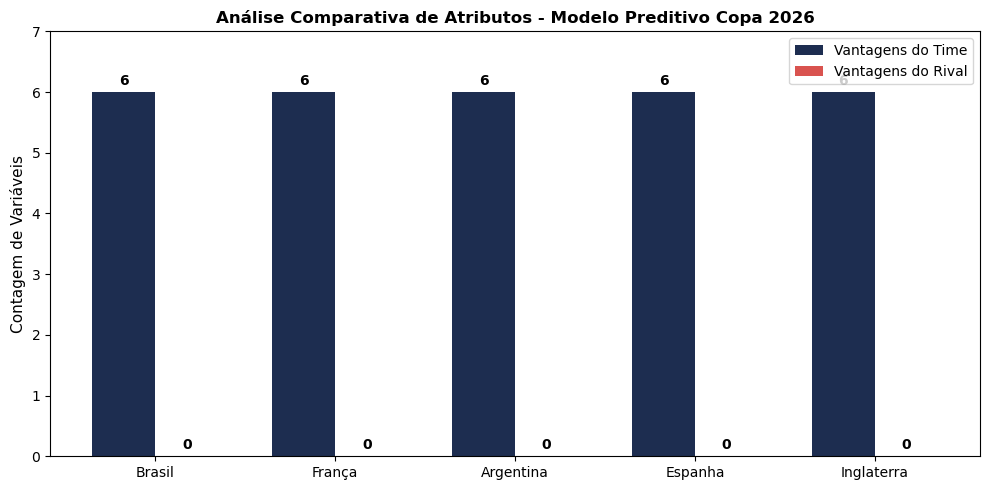

In [3]:
# Código de plotagem (Gera o gráfico direto no output da célula do Jupyter)
x = np.arange(len(df_plot['Seleção']))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width/2, df_plot['Vantagens Conquistadas'], width, label='Vantagens do Time', color='#1d2d50')
rects2 = ax.bar(x + width/2, df_plot['Vantagens Cedidas'], width, label='Vantagens do Rival', color='#d9534f')

ax.set_ylabel('Contagem de Variáveis', fontsize=11)
ax.set_title('Análise Comparativa de Atributos - Modelo Preditivo Copa 2026', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_plot['Seleção'])
ax.legend()
ax.set_ylim(0, 7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('../'))

from src.features import simular_confronto_direto


dados_selecoes = {
    'Brasil': {'elo': 2010, 'ranking_fifa': 5, 'estilo_jogo': 8.5, 'defesa': 0.8, 'valor_elenco_milhoes': 95.0, 'aproveitamento_recente': 0.70},
    'França': {'elo': 2060, 'ranking_fifa': 2, 'estilo_jogo': 8.0, 'defesa': 0.7, 'valor_elenco_milhoes': 102.0, 'aproveitamento_recente': 0.75},
    'Argentina': {'elo': 2120, 'ranking_fifa': 1, 'estilo_jogo': 7.5, 'defesa': 0.5, 'valor_elenco_milhoes': 80.0, 'aproveitamento_recente': 0.85},
    'Espanha': {'elo': 2040, 'ranking_fifa': 3, 'estilo_jogo': 9.0, 'defesa': 0.6, 'valor_elenco_milhoes': 88.0, 'aproveitamento_recente': 0.80},
    'Inglaterra': {'elo': 1990, 'ranking_fifa': 4, 'estilo_jogo': 7.0, 'defesa': 0.9, 'valor_elenco_milhoes': 110.0, 'aproveitamento_recente': 0.65}
}


df_selecoes = pd.DataFrame(dados_selecoes).T


referencia_media = pd.Series({
    'elo': 1900,
    'ranking_fifa': 15,
    'estilo_jogo': 6.0,
    'defesa': 1.2,
    'valor_elenco_milhoes': 45.0,
    'aproveitamento_recente': 0.50
})


df_com_adversario = pd.concat([
    df_selecoes,
    pd.DataFrame([referencia_media], index=['Adversario_Medio'])
])


resultados_plot = []


for selecao in df_selecoes.index:

    v_time, v_adv = simular_confronto_direto(
        selecao,
        'Adversario_Medio',
        df_com_adversario
    )

    resultados_plot.append({
        'Seleção': selecao,
        'Vantagens Conquistadas': v_time,
        'Vantagens Cedidas': v_adv
    })


df_plot = pd.DataFrame(resultados_plot)


df_plot

,Seleção,Vantagens Conquistadas,Vantagens Cedidas
0,Brasil,6,0
1,França,6,0
2,Argentina,6,0
3,Espanha,6,0
4,Inglaterra,6,0
